# Importing The libraries

In [1]:
import pandas as pd
from pathlib import Path
import pyarrow.parquet as pq
from dataclasses import dataclass
import hvplot.pandas 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import re
import os

# Data loading

We'll just be loading the unit 5 training and synthetic dataset

In [2]:
dataset_root = Path(r"./dataset") # Raw string works without escaping \


@dataclass
class Case():
    info: pd.DataFrame
    measurements: pd.DataFrame


class RawDataset():

    def __init__(self, root, unit = "VG4", load_training=False, load_synthetic=False) -> None:
        
        
        read_pq_file = lambda f: pq.read_table(root / f).to_pandas()
        
        
        cases = {
            "test": [f"{unit}_generator_data_testing_real_measurements.parquet", root / f"{unit}_generator_data_testing_real_info.csv" ], 
        }
        
        if load_training:
            cases = {
                **cases,
                "train": [f"{unit}_generator_data_training_measurements.parquet", root / f"{unit}_generator_data_training_info.csv" ], 
            }
        
        if load_synthetic:
            cases = {
                **cases,
                "test_s01": [f"{unit}_generator_data_testing_synthetic_01_measurements.parquet", root / f"{unit}_generator_data_testing_synthetic_01_info.csv"], 
                "test_s02": [f"{unit}_generator_data_testing_synthetic_02_measurements.parquet", root / f"{unit}_generator_data_testing_synthetic_02_info.csv"]
            }
        
        
        self.data_dict = dict()
        
        for id_c, c in cases.items():
            # if you need to verify the parquet header:
            # pq_rows = RawDataset.read_parquet_schema_df(root / c[0])
            info = pd.read_csv(c[1])
            measurements = read_pq_file(c[0])
            self.data_dict[id_c] = Case(info, measurements)
            
        
        
    @staticmethod
    def read_parquet_schema_df(uri: str) -> pd.DataFrame:
        """Return a Pandas dataframe corresponding to the schema of a local URI of a parquet file.

        The returned dataframe has the columns: column, pa_dtype
        """
        # Ref: https://stackoverflow.com/a/64288036/
        schema = pq.read_schema(uri, memory_map=True)
        schema = pd.DataFrame(({"column": name, "pa_dtype": str(pa_dtype)} for name, pa_dtype in zip(schema.names, schema.types)))
        schema = schema.reindex(columns=["column", "pa_dtype"], fill_value=pd.NA)  # Ensures columns in case the parquet file has an empty dataframe.
        return schema

In [3]:
rds_u5_synth = RawDataset(dataset_root, "VG5", load_synthetic=False, load_training=True)

# Splitting the dataframes

The dataframes are split between the time series measured by the sensors ($Y_t$), the control time series ($X_t$) and the operating modes (OP).

#### Helper function to split the data 

In [4]:
# Define Operating Modes
Operating_modes_name = [
    "turbine_mode", "equilibrium_turbine_mode", "pump_mode", "equilibrium_pump_mode",
    "short_circuit_mode", "equilibrium_short_circuit_mode", "machine_on", "machine_off", 
    "dyn_only_on", "all"
]

# Time Series Extraction Functions
def extracting_name_groups_time_series(rds, set_type):
    df_name_control_sensors = rds.data_dict[set_type].info
    control_time_series_name = df_name_control_sensors[
        (df_name_control_sensors['control_signal'] == True) &
        (df_name_control_sensors["signal_type"] == "Measurement")
    ]
    sensors_time_series_name = df_name_control_sensors[
        (df_name_control_sensors['control_signal'] == False) &
        (df_name_control_sensors["signal_type"] == "Measurement")
    ]
    return control_time_series_name["attribute_name"], sensors_time_series_name["attribute_name"]

def extracting_groups_time_series(rds, set_type):
    control_time_series_name, sensors_time_series_name = extracting_name_groups_time_series(rds, set_type=set_type)
    control_df = rds.data_dict[set_type].measurements[control_time_series_name]
    sensors_df = rds.data_dict[set_type].measurements[sensors_time_series_name]
    operating_modes_df = rds.data_dict[set_type].measurements[Operating_modes_name]
    return control_df, sensors_df, operating_modes_df

def get_indexes_operating_mode(operating_modes_df, operating_conditions):
    mask = pd.Series([True] * len(operating_modes_df), index=operating_modes_df.index)
    for column, value in operating_conditions.items():
        mask &= (operating_modes_df[column] == value)
    return operating_modes_df[mask].index

# Helper functions for feature extraction and normalization
def create_scaled_sum_feature(df, feature_prefixes, new_feature_name):
    feature_columns = df.columns[df.columns.str.startswith(tuple(feature_prefixes))]
    df[new_feature_name] = df[feature_columns].sum(axis=1)
    scaler = MinMaxScaler()
    df[new_feature_name] = scaler.fit_transform(df[[new_feature_name]])
    df.drop(columns=feature_columns, inplace=True)
    return df

def normalize_features(df):
    scaler = MinMaxScaler()
    numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns
    df[numerical_columns] = scaler.fit_transform(df[numerical_columns])
    return df

def dynamic_group_features(df):
    feature_groups = {
        'voltage_current': df.columns[df.columns.str.startswith(("exc", "ph", "elec", "mid", "neutral"))].tolist(),
        'stator_temperature': df.columns[df.columns.str.startswith("stat_") & 
                                         df.columns.str.contains("coil|magn")].tolist(),
        'cooling_system': df.columns[df.columns.str.startswith("air_circ_")].tolist(),
        'heat_exchanger': df.columns[df.columns.str.startswith("water_circ_")].tolist()
    }

    # Flatten the list of all grouped features
    grouped_features = [feature for group in feature_groups.values() for feature in group]
    # Find complementary features
    complementary_features = [col for col in df.columns if col not in grouped_features]
    
    feature_groups['complementary'] = complementary_features

    return feature_groups

In [5]:
def preprocess_hydraulic_data(rds, set_type, operating_conditions):
    """
    Preprocess the hydraulic site data to return normalized control and sensor signals filtered by operating conditions.

    Parameters:
    - rds: RawDataset object containing the data dictionary
    - set_type: Type of dataset to use ('train', 'test', etc.)
    - feature_group: The group of sensor features to select for preprocessing
    - operating_conditions: A dictionary specifying operating conditions to filter the data
    
    Returns:
    - Dictionary with two normalized and filtered DataFrames: control signals and sensor signals
    """
    # Step 1: Extract control, sensor, and operating mode time series
    control_df, sensors_df, operating_modes_df = extracting_groups_time_series(rds, set_type=set_type)

    # Step 2: Filter based on operating conditions if specified
    if operating_conditions:
        indexes = get_indexes_operating_mode(operating_modes_df, operating_conditions)
        control_df = control_df.loc[indexes]
        sensors_df = sensors_df.loc[indexes]
        
    # Select features containing both 'water' and 'opening' in their name
    water_opening_features = [col for col in control_df.columns if "water" in col and "opening" in col]
    control_df = create_scaled_sum_feature(control_df, water_opening_features, "water_opening_sum")

    # Select features containing both 'injector' and 'opening' in their name
    injector_opening_features = [col for col in control_df.columns if "injector" in col and "opening" in col]
    control_df = create_scaled_sum_feature(control_df, injector_opening_features, "injector_opening_sum")

    # Step 4: Normalize the control and sensor DataFrames
    control_df = normalize_features(control_df)
    sensors_df = normalize_features(sensors_df)

    # Step 5: Select only the sensor features corresponding to the specified feature group
    grouped_data = dynamic_group_features(sensors_df)
    selected_sensor_data = []
    for key in grouped_data.keys():
        selected_sensor_data.append(sensors_df[grouped_data[key]])

    return {
        'control_signals': control_df,
        'sensor_signals': selected_sensor_data
    }

In [6]:
# Example Usage
# Define the operating conditions for turbine steady state
operating_conditions_turbine_steady_state = {
    "dyn_only_on": False, "turbine_mode": True, "equilibrium_turbine_mode": True, "short_circuit_mode": False
}

# Preprocess data to get normalized control and sensor signals based on conditions
rds_u5_turb_ss_volt = preprocess_hydraulic_data(
    rds_u5_synth, set_type="train", operating_conditions=operating_conditions_turbine_steady_state
)

In [7]:
del rds_u5_synth # To free memory
control_df = rds_u5_turb_ss_volt['control_signals']
sensors_df = rds_u5_turb_ss_volt['sensor_signals']

In [8]:
numb_sensors = 0

for i in range(len(sensors_df)):
    numb_sensors += len(sensors_df[i].columns)

numb_sensors ## A quick sanity check to see if all the columns are kept

75

In [9]:
sensors_voltage_current = sensors_df[0]
sensors_stator_temperature = sensors_df[1]
sensors_cooling_system = sensors_df[2]
sensors_heat_exchanger = sensors_df[3]
sensors_other = sensors_df[4]

In [10]:
### What is the number of time series for each sensor dataframe ?

for i in range(len(sensors_df)):
    print(f"The number of time series is : {len(sensors_df[i].columns)}")

The number of time series is : 14
The number of time series is : 30
The number of time series is : 12
The number of time series is : 9
The number of time series is : 10


In [11]:
def cleaning_control_signals_turbine(df):
    control_df = df
    ### Preprocessing for the turbine mode
    water_opening_columns = control_df.columns[
        control_df.columns.str.startswith("water")]
    
    # Dropping the useless columns
    control_df = control_df.drop(columns=water_opening_columns)
    control_df = control_df.drop(columns="pump_calculated_flow")
    return control_df

In [12]:
control_df = cleaning_control_signals_turbine(control_df)

control_df.shape

(332235, 7)

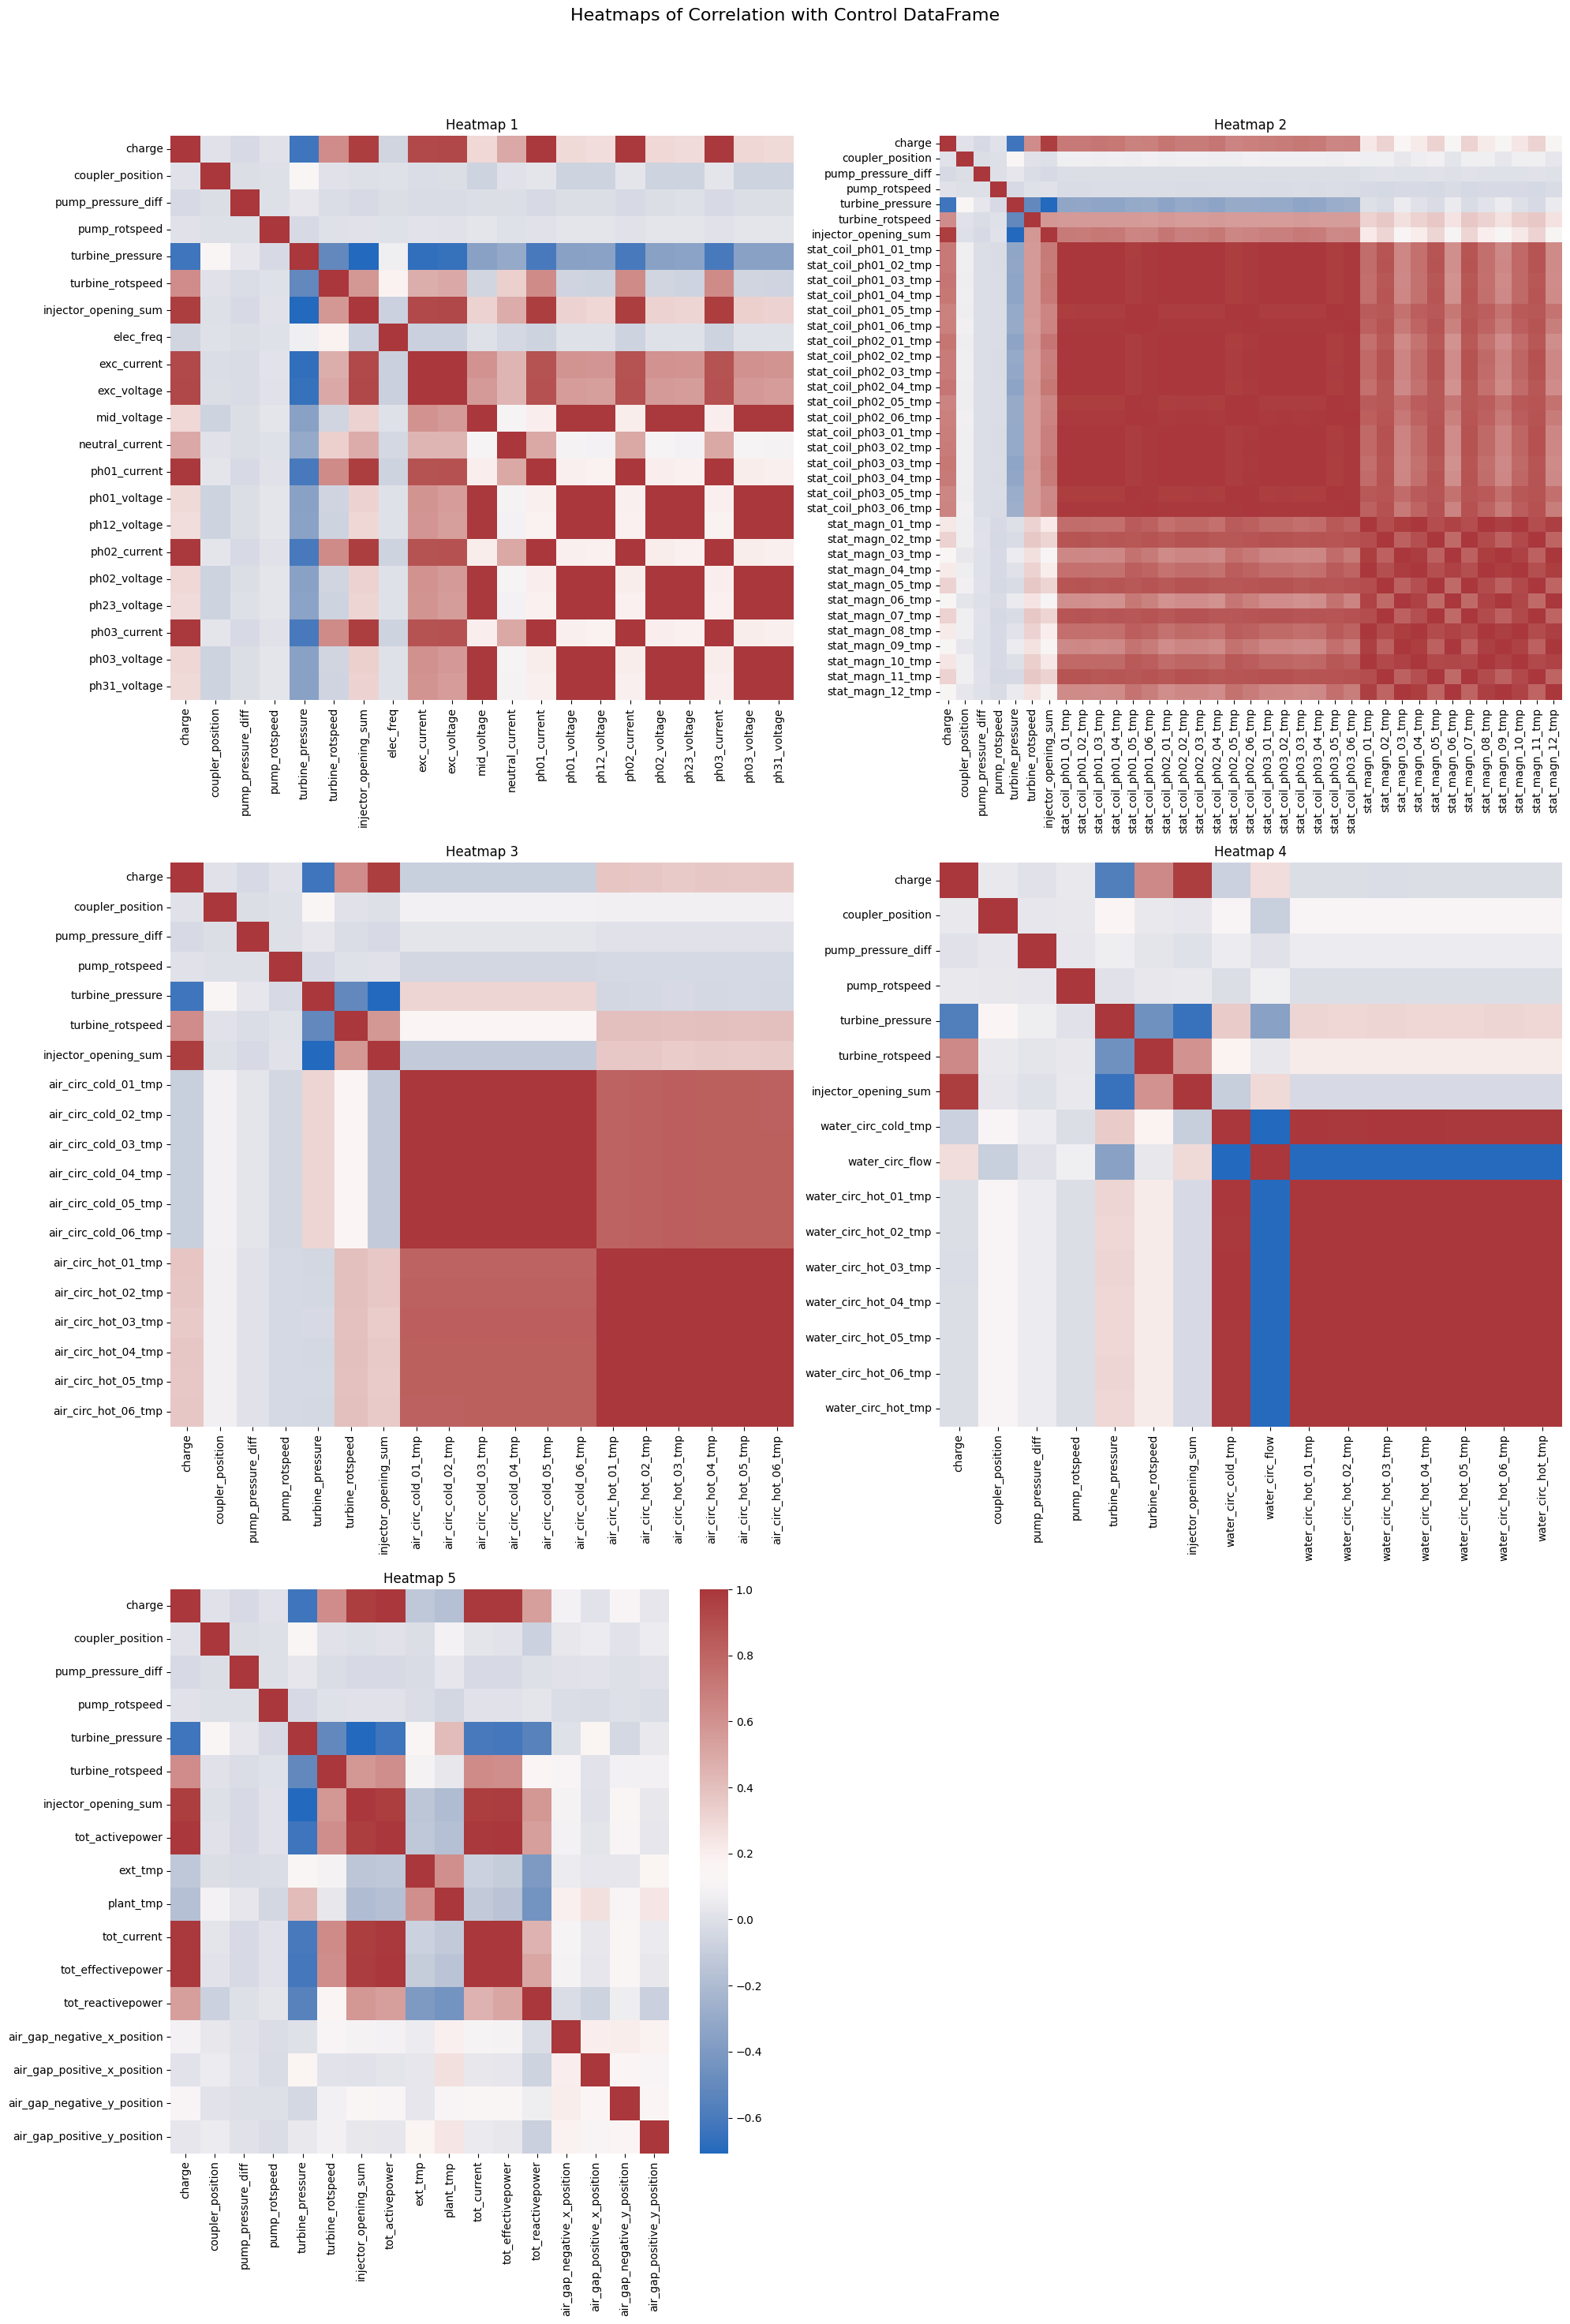

In [13]:
# Set up the subplots with at most 2 plots per row
rows = (len(sensors_df) + 1) // 2
fig, axs = plt.subplots(rows, 2, figsize=(20, 10 * rows))

for i in range(len(sensors_df)):
    # Determine the subplot location
    row = i // 2
    col = i % 2
    
    # Concatenate control_df with the current sensor DataFrame
    buffer = pd.concat([control_df, sensors_df[i]], axis=1)
    
    # Compute the correlation matrix
    corr_matrix = buffer.corr() ### Could add subsampling
    
    # Plot the heatmap
    sns.heatmap(corr_matrix, cmap="vlag", ax=axs[row, col], cbar=(i == len(sensors_df) - 1))
    axs[row, col].set_title(f"Heatmap {i+1}")

# Remove empty subplots if sensors_df has an odd number of elements
if len(sensors_df) % 2 != 0:
    fig.delaxes(axs[-1, -1])

# Set the overall title
plt.suptitle("Heatmaps of Correlation with Control DataFrame", fontsize=16)

# Adjust the layout to prevent overlap
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Show the plots
plt.show()

In [14]:
# Calculate time differences between consecutive non-NaN values
time_series = control_df['turbine_rotspeed']
valid_data = time_series[time_series.notna()]
time_gaps = valid_data.index.to_series().diff()

# Define threshold for splitting operations
gap_threshold = pd.Timedelta(hours=72)

# Create new groups when gap is larger than threshold
new_operation = (time_gaps > gap_threshold).cumsum()
operation_groups = pd.Series(index=time_series.index, data=None)
operation_groups[valid_data.index] = new_operation

# Assign operation groups to main dataframe
control_df['operation_group'] = operation_groups

# Split into operation periods
operating_periods = []
for group in control_df.groupby('operation_group'):
    if not group[1]['turbine_rotspeed'].isna().all():  # Only keep periods with data
        operating_periods.append(group[1])

# Print info about each period
for i, period in enumerate(operating_periods):
    print(f"Operation Period {i}:")
    print(f"Start: {period.index[0]}")
    print(f"End: {period.index[-1]}")
    print(f"Duration: {period.index[-1] - period.index[0]}")
    print(f"Downtime before next operation: {operating_periods[i+1].index[0] - period.index[-1] if i < len(operating_periods)-1 else 'N/A'}")
    print(f"Number of time samples: {len(period)}\n")

Operation Period 0:
Start: 2020-01-05 07:05:30+01:00
End: 2020-04-01 23:48:30+02:00
Duration: 87 days 15:43:00
Downtime before next operation: 3 days 22:39:30
Number of time samples: 99218

Operation Period 1:
Start: 2020-04-05 22:28:00+02:00
End: 2020-05-30 22:58:30+02:00
Duration: 55 days 00:30:30
Downtime before next operation: 18 days 10:59:00
Number of time samples: 57864

Operation Period 2:
Start: 2020-06-18 09:57:30+02:00
End: 2020-07-30 08:59:00+02:00
Duration: 41 days 23:01:30
Downtime before next operation: 3 days 00:11:30
Number of time samples: 48029

Operation Period 3:
Start: 2020-08-02 09:10:30+02:00
End: 2020-08-13 21:55:30+02:00
Duration: 11 days 12:45:00
Downtime before next operation: 9 days 15:34:30
Number of time samples: 16121

Operation Period 4:
Start: 2020-08-23 13:30:00+02:00
End: 2020-12-09 20:03:30+01:00
Duration: 108 days 07:33:30
Downtime before next operation: 3 days 12:26:00
Number of time samples: 90402

Operation Period 5:
Start: 2020-12-13 08:29:30+0

## Saving the first two operation time

In [15]:
operation_time_0 = operation_groups[operation_groups==0].index

control_op_0_df = control_df.loc[operation_time_0]
control_op_0_df = control_op_0_df.drop(columns="operation_group")
sensors_voltage_current_op_0 = sensors_voltage_current.loc[operation_time_0]
sensors_stator_temperature_op_0 = sensors_stator_temperature.loc[operation_time_0]
sensors_cooling_system_op_0 = sensors_cooling_system.loc[operation_time_0]
sensors_heat_exchanger_op_0 = sensors_heat_exchanger.loc[operation_time_0]
sensors_other_op_0 = sensors_other.loc[operation_time_0]

In [16]:
control_op_0_df.shape

(99218, 7)

In [17]:
save_directory = './preprocessed_dataset/VG5/op_0'

os.makedirs(save_directory, exist_ok=True)

control_op_0_df.to_parquet(path=f'{save_directory}/control.parquet')
sensors_voltage_current_op_0.to_parquet(path=f'{save_directory}/sensors_voltage_current.parquet')
sensors_stator_temperature_op_0.to_parquet(path=f'{save_directory}/sensors_stator_temperature.parquet')
sensors_cooling_system_op_0.to_parquet(path=f'{save_directory}/sensors_cooling_system.parquet')
sensors_heat_exchanger_op_0.to_parquet(path=f'{save_directory}/sensors_heat_exchanger.parquet')
sensors_other_op_0.to_parquet(path=f'{save_directory}/sensors_other.parquet')

In [18]:
operation_time_1 = operation_groups[operation_groups==1].index

control_op_1_df = control_df.loc[operation_time_1]
control_op_1_df = control_op_1_df.drop(columns="operation_group")
sensors_voltage_current_op_1 = sensors_voltage_current.loc[operation_time_1]
sensors_stator_temperature_op_1 = sensors_stator_temperature.loc[operation_time_1]
sensors_cooling_system_op_1 = sensors_cooling_system.loc[operation_time_1]
sensors_heat_exchanger_op_1 = sensors_heat_exchanger.loc[operation_time_1]
sensors_other_op_1 = sensors_other.loc[operation_time_1]

save_directory = './preprocessed_dataset/VG5/op_1'

os.makedirs(save_directory, exist_ok=True)

control_op_1_df.to_parquet(path=f'{save_directory}/control.parquet')
sensors_voltage_current_op_1.to_parquet(path=f'{save_directory}/sensors_voltage_current.parquet')
sensors_stator_temperature_op_1.to_parquet(path=f'{save_directory}/sensors_stator_temperature.parquet')
sensors_cooling_system_op_1.to_parquet(path=f'{save_directory}/sensors_cooling_system.parquet')
sensors_heat_exchanger_op_1.to_parquet(path=f'{save_directory}/sensors_heat_exchanger.parquet')
sensors_other_op_1.to_parquet(path=f'{save_directory}/sensors_other.parquet')

## Saving the synthetic dataset

In [19]:
rds_u5_synth = RawDataset(dataset_root, "VG5", load_synthetic=True, load_training=False)

rds_u5_turb_ss_volt=preprocess_hydraulic_data(
                                            rds_u5_synth, 
                                            set_type="test_s01",
                                            operating_conditions=operating_conditions_turbine_steady_state
                                        )

del rds_u5_synth # To free memory
control_df = rds_u5_turb_ss_volt['control_signals']
sensors_df = rds_u5_turb_ss_volt['sensor_signals']

control_df = cleaning_control_signals_turbine(control_df)

sensors_voltage_current = sensors_df[0]
sensors_stator_temperature = sensors_df[1]
sensors_cooling_system = sensors_df[2]
sensors_heat_exchanger = sensors_df[3]
sensors_other = sensors_df[4]

save_directory = './preprocessed_dataset/VG5/s_01'

os.makedirs(save_directory, exist_ok=True)

control_df.to_parquet(path=f'{save_directory}/control.parquet')
sensors_voltage_current.to_parquet(path=f'{save_directory}/sensors_voltage_current.parquet')
sensors_stator_temperature.to_parquet(path=f'{save_directory}/sensors_stator_temperature.parquet')
sensors_cooling_system.to_parquet(path=f'{save_directory}/sensors_cooling_system.parquet')
sensors_heat_exchanger.to_parquet(path=f'{save_directory}/sensors_heat_exchanger.parquet')
sensors_other.to_parquet(path=f'{save_directory}/sensors_other.parquet')